# SLO Analysis

Extracts **isolated** (non-overlapping) latencies across RPU levels 4–256,
computes three SLO-tightness tables (`k = 1.5, 2.5, 4.0`), and visualises
the resulting SLO landscape.

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import autoslo.filesystem.path_utils as pu
from autoslo.visualizations.colors import Palette, set_plot_colors
from autoslo.slo.slo_table import (
    compute_isolated_latencies,
    compute_slo_dict,
    dump_slo_table,
)

In [9]:
# ── Stub: provide run IDs for each RPU level ──

def get_run_ids_for_rpu(rpu: int) -> list[str]:
    """Return isolated-run IDs for the given RPU."""
    return pu.RunLocator.get_run_ids(
                workload_name="benchmarking_workload_99_3_3_shuffled_42",
                blueprint_name=f"single_{rpu}",
            )[-1:]

RPUS = [4, 8, 16, 32]

all_run_ids = []
for rpu in RPUS:
    all_run_ids.extend(get_run_ids_for_rpu(rpu))

print(f"Total runs: {len(all_run_ids)}")

Total runs: 4


In [10]:
# ── Compute isolated latencies ──

latencies_df = compute_isolated_latencies(all_run_ids)
print(f"{len(latencies_df)} isolated measurements across {latencies_df['rpu'].nunique()} RPU levels.")
latencies_df.head()

3564 isolated measurements across 4 RPU levels.


,run_id,rpu,tpcds_temp_and_q_idx,latency_s
0,1759429111,4,086_003,10.670330
1,1759429111,4,082_001,28.500305
2,1759429111,4,099_001,25.584857
3,1759429111,4,020_002,13.112147
4,1759429111,4,088_001,181.408244


In [2]:
# ── Persist isolated latencies ──

slo_dir = os.path.join(pu.get_data_path(), "slos")
os.makedirs(slo_dir, exist_ok=True)
latencies_path = os.path.join(slo_dir, "isolated_latencies.parquet")
latencies_df = pd.read_parquet(latencies_path)
print(f"Loaded from {latencies_path}")

Loaded from /home/markakis/chunkbench/data/slos/isolated_latencies.parquet


In [3]:
# ── SLO parameters ──

REFERENCE_RPU = 16
BASELINE_PERCENTILES = [50.0, 90.0, 95.0]   
MULTIPLIERS = [1.5, 2.5, 4.0]  # tight, moderate, loose

slo_dicts = {}
for k in MULTIPLIERS:
    for p in BASELINE_PERCENTILES:
        print(f"Computing SLOs for k={k}, baseline_percentile={p}...")
        slo = dump_slo_table(
            latencies_df,
            rpu=REFERENCE_RPU,
            baseline_percentile=p,
            multiplier=k,
            workload_tag="ext_tpcds1000",
        )
        slo_dicts[k] = slo
        print(f"k={k}: {len(slo)} SLOs written.")

Computing SLOs for k=1.5, baseline_percentile=50.0...
k=1.5: 99 SLOs written.
Computing SLOs for k=1.5, baseline_percentile=90.0...
k=1.5: 99 SLOs written.
Computing SLOs for k=1.5, baseline_percentile=95.0...
k=1.5: 99 SLOs written.
Computing SLOs for k=2.5, baseline_percentile=50.0...
k=2.5: 99 SLOs written.
Computing SLOs for k=2.5, baseline_percentile=90.0...
k=2.5: 99 SLOs written.
Computing SLOs for k=2.5, baseline_percentile=95.0...
k=2.5: 99 SLOs written.
Computing SLOs for k=4.0, baseline_percentile=50.0...
k=4.0: 99 SLOs written.
Computing SLOs for k=4.0, baseline_percentile=90.0...
k=4.0: 99 SLOs written.
Computing SLOs for k=4.0, baseline_percentile=95.0...
k=4.0: 99 SLOs written.


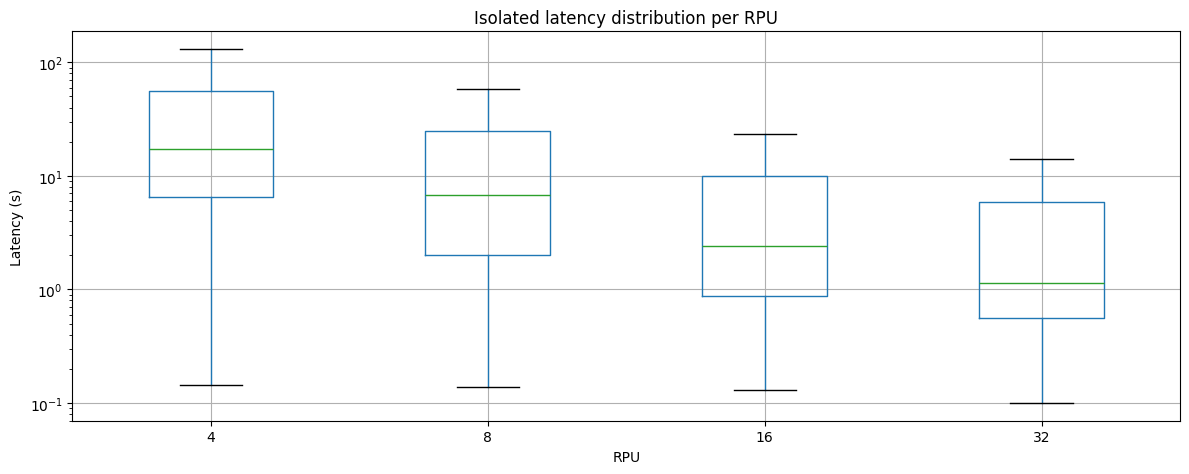

In [13]:
# ── Plot 1: Isolated-latency distribution per RPU ──

fig, ax = plt.subplots(figsize=(12, 5))
latencies_df.boxplot(
    column="latency_s",
    by="rpu",
    ax=ax,
    showfliers=False,
)
ax.set_title("Isolated latency distribution per RPU")
ax.set_xlabel("RPU")
ax.set_ylabel("Latency (s)")
ax.set_yscale("log")
plt.suptitle("")
plt.tight_layout()
plt.savefig("latency_per_rpu.svg", dpi=150)
plt.show()

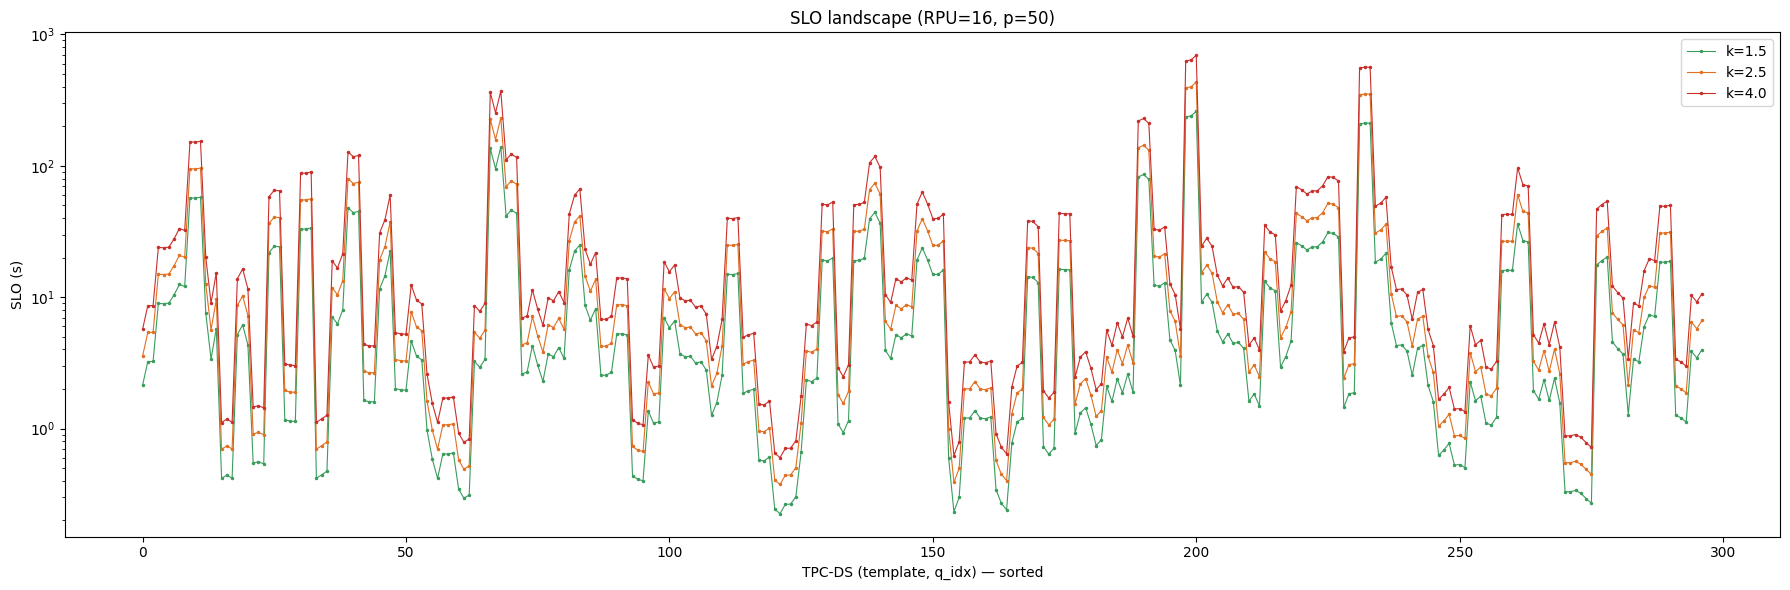

In [14]:
# ── Plot 2: SLO values across templates for each tightness level ──

fig, ax = plt.subplots(figsize=(18, 6))
colors = {1.5: Palette.dark_green, 2.5: Palette.dark_orange, 4.0: Palette.dark_red}

for k, slo in slo_dicts.items():
    slo_series = pd.Series(slo).sort_index()
    ax.plot(
        range(len(slo_series)),
        slo_series.values,
        label=f"k={k}",
        color=colors[k],
        marker=".",
        markersize=3,
        linewidth=0.8,
    )

ax.set_xlabel("TPC-DS (template, q_idx) — sorted")
ax.set_ylabel("SLO (s)")
ax.set_yscale("log")
ax.set_title(f"SLO landscape (RPU={REFERENCE_RPU}, p={int(BASELINE_PERCENTILE)})")
ax.legend()
plt.tight_layout()
plt.savefig("slo_landscape.svg", dpi=150)
plt.show()

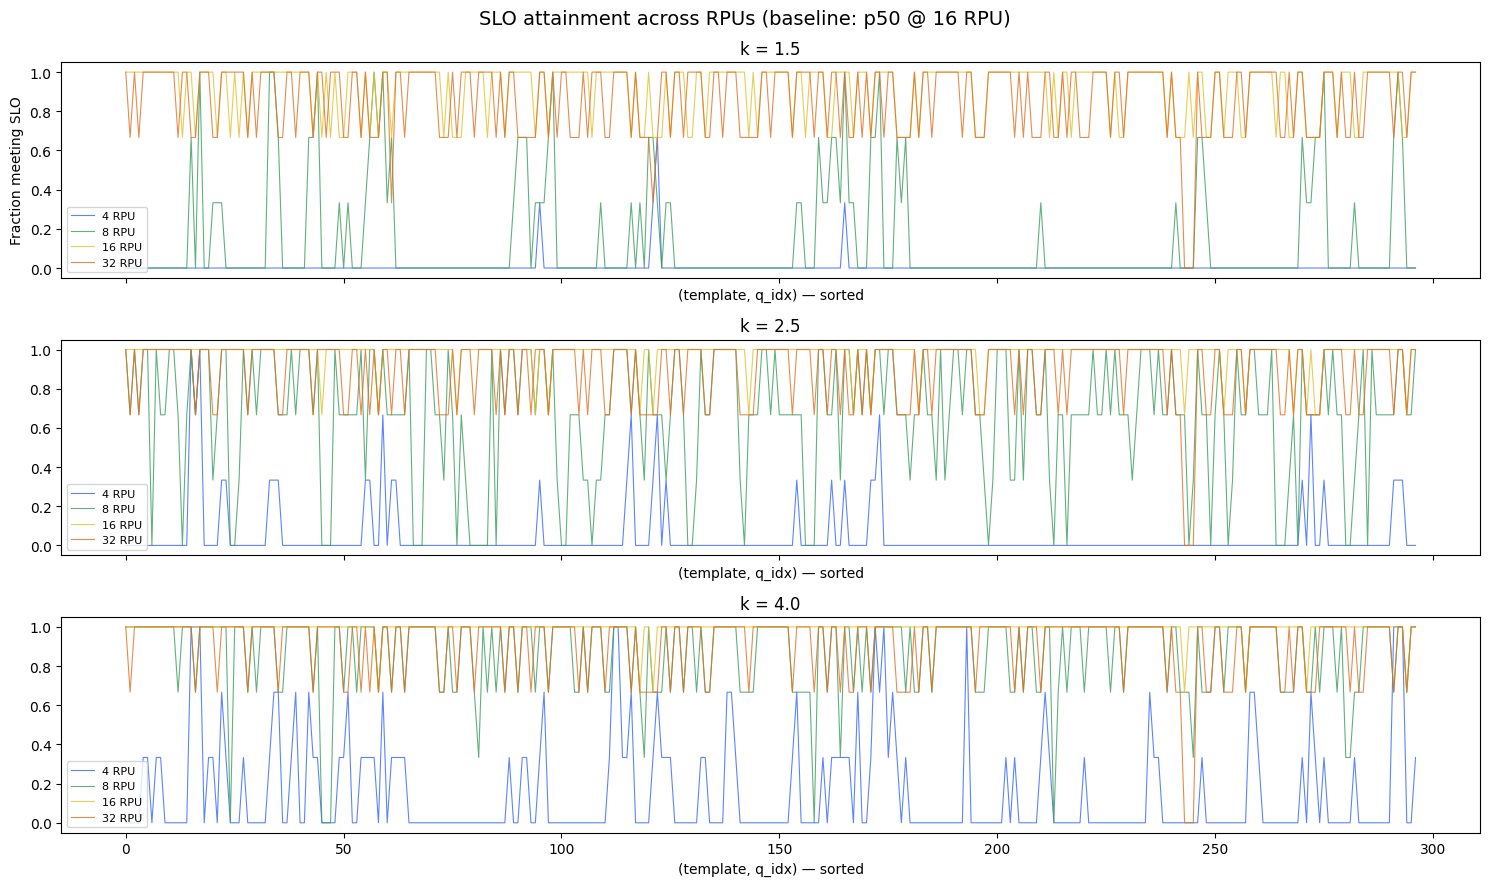

In [15]:
# ── Plot 3: Fraction of executions meeting SLO at each RPU ──

fig, axes = plt.subplots(len(MULTIPLIERS),1,  figsize=(15, 3 * len(MULTIPLIERS)), sharex=True)

rpu_colors = {
    4: Palette.dark_blue,
    8: Palette.dark_green,
    16: Palette.dark_yellow,
    32: Palette.dark_orange,
    64: Palette.dark_red,
    128: Palette.dark_purple if hasattr(Palette, 'dark_purple') else '#7b2d8e',
    256: '#333333',
}

for ax, k in zip(axes, MULTIPLIERS):
    slo = pd.Series(slo_dicts[k])
    for rpu in RPUS:
        subset = latencies_df[latencies_df["rpu"] == rpu]
        fraction_meeting = (
            subset.groupby("tpcds_temp_and_q_idx")
            .apply(
                lambda g: (g["latency_s"] <= slo.get(g.name, np.inf)).mean(),
                include_groups=False,
            )
            .sort_index()
        )
        ax.plot(
            range(len(fraction_meeting)),
            fraction_meeting.values,
            label=f"{rpu} RPU",
            color=rpu_colors.get(rpu, "gray"),
            alpha=0.8,
            linewidth=0.8,
        )
    ax.set_title(f"k = {k}")
    ax.set_xlabel("(template, q_idx) — sorted")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8, loc="lower left")

axes[0].set_ylabel("Fraction meeting SLO")
fig.suptitle(
    f"SLO attainment across RPUs (baseline: p{int(BASELINE_PERCENTILE)} @ {REFERENCE_RPU} RPU)",
    fontsize=14,
)
plt.tight_layout()
plt.savefig("slo_attainment.svg", dpi=150)
plt.show()